# Introduction

In previous notebooks, we implemented and evaluated several adversarial attacks, including **FGSM**, **DeepFool**, and **PGD**.  
These attacks were applied **after** the model was trained, with the goal of measuring its vulnerability.  
In other words, the model was fixed, and the adversarial attack attempted to *break it*.

This notebook focuses on a fundamentally different concept: **adversarial training**.

### PGD Attack (what we did before) :
- The model is already trained
- We generate adversarial examples using PGD
- We evaluate how accuracy drops
- Purpose: **measure vulnerability**

This is a *test-time* attack.

### PGD Adversarial Training (what we will do in this notebook ) :
- During training, each batch is replaced by PGD adversarial examples
- The model learns from these adversarial samples continuously
- Purpose: **increase robustness** by making the model resistant to PGD and similar attacks.

This is a *training-time defense strategy*.

### Why it matters :
PGD adversarial training is considered the " **gold standard** " for building robust neural networks.  
A PGD-trained model typically:

- has slightly lower clean accuracy
- but remains **much more resistant** to adversarial attacks !

The goal of this notebook is to train two models:
1. a standard model
2. a PGD-trained robust model

and compare their performance under attacks.

This will let us clearly observe the difference between:
- a normal model (very vulnerable), and  
- a robust model (significantly more resistant).


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=1000, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.55MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


In [3]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

model_clean = Net().to(device)
model_robust = Net().to(device)


In [4]:
# The previous PGD attack ( standard model )
def pgd_attack(model, images, labels, eps=0.3, alpha=0.01, iters=40):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    ori_images = images.clone()

    for i in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()
        grad = images.grad.sign()

        images = images + alpha * grad
        eta = torch.clamp(images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, 0, 1).detach()

    return images


In [6]:
# Standard Training function

def train_clean(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(2):  # rapide
        loop = tqdm(train_loader, desc=f"Clean Training Epoch {epoch+1}")
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = nn.CrossEntropyLoss()(pred, y)
            loss.backward()
            optimizer.step()


In [7]:
# Robust Training function (PGD Adversarial Training)

def train_pgd(model, eps=0.3, alpha=0.01, iters=40):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()

    for epoch in range(2):
        loop = tqdm(train_loader, desc=f"PGD Adversarial Training Epoch {epoch+1}")
        for x, y in loop:
            x, y = x.to(device), y.to(device)

            # Générer adversarial examples
            x_adv = pgd_attack(model, x, y, eps=eps, alpha=alpha, iters=iters)

            optimizer.zero_grad()
            pred = model(x_adv)
            loss = nn.CrossEntropyLoss()(pred, y)
            loss.backward()
            optimizer.step()






In [8]:
train_clean(model_clean)
train_pgd(model_robust)


PGD Adversarial Training Epoch 2: 100%|██████████| 938/938 [01:52<00:00,  8.37it/s]


In [11]:
def eval_model(model, attack=None):
    model.eval()
    correct = 0
    total = 0

    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        if attack is not None:
            x = attack(model, x, y)
            with torch.no_grad():
                pred = model(x).argmax(1)
        else:
            with torch.no_grad():
                pred = model(x).argmax(1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    return correct / total


In [12]:
acc_clean_clean = eval_model(model_clean)
acc_robust_clean = eval_model(model_robust)

acc_clean_pgd = eval_model(model_clean, attack=lambda m,x,y: pgd_attack(m,x,y))
acc_robust_pgd = eval_model(model_robust, attack=lambda m,x,y: pgd_attack(m,x,y))

print("Normal model — Clean accuracy:      ", acc_clean_clean)
print("Robust model — Clean accuracy:      ", acc_robust_clean)
print("Normal model — Under PGD attack:    ", acc_clean_pgd)
print("Robust model — Under PGD attack:    ", acc_robust_pgd)


Normal model — Clean accuracy:       0.987
Robust model — Clean accuracy:       0.9709
Normal model — Under PGD attack:     0.0
Robust model — Under PGD attack:     0.7912


## Performance Analysis

The results show a clear and expected contrast between the standard model and the PGD-trained model:

- **Normal model , Clean accuracy: 98.7%**  
  → As expected, the baseline CNN performs very well on unperturbed MNIST images.

- **Robust model , Clean accuracy: 97.1%**  
  → A small drop in clean accuracy (~1.6%) is typical and well-documented in adversarial training.  
    The model trades a bit of clean accuracy for stronger robustness.

- **Normal model , Under PGD attack: 0.0%**  
  → The baseline model is completely broken by PGD.  
    This confirms our earlier findings: standard training offers *no protection* against strong iterative attacks.

- **Robust model ,  Under PGD attack: 79.1%**  
  → The robust model remains highly accurate even under a strong PGD attack.  
    This demonstrates the effectiveness of PGD adversarial training:  
    the model learns to resist the very attack it is trained with.

# Result:  
## The PGD-trained model is dramatically more robust-recovering more than **+79% accuracy** under PGD, compared to **0%** for the standard network.


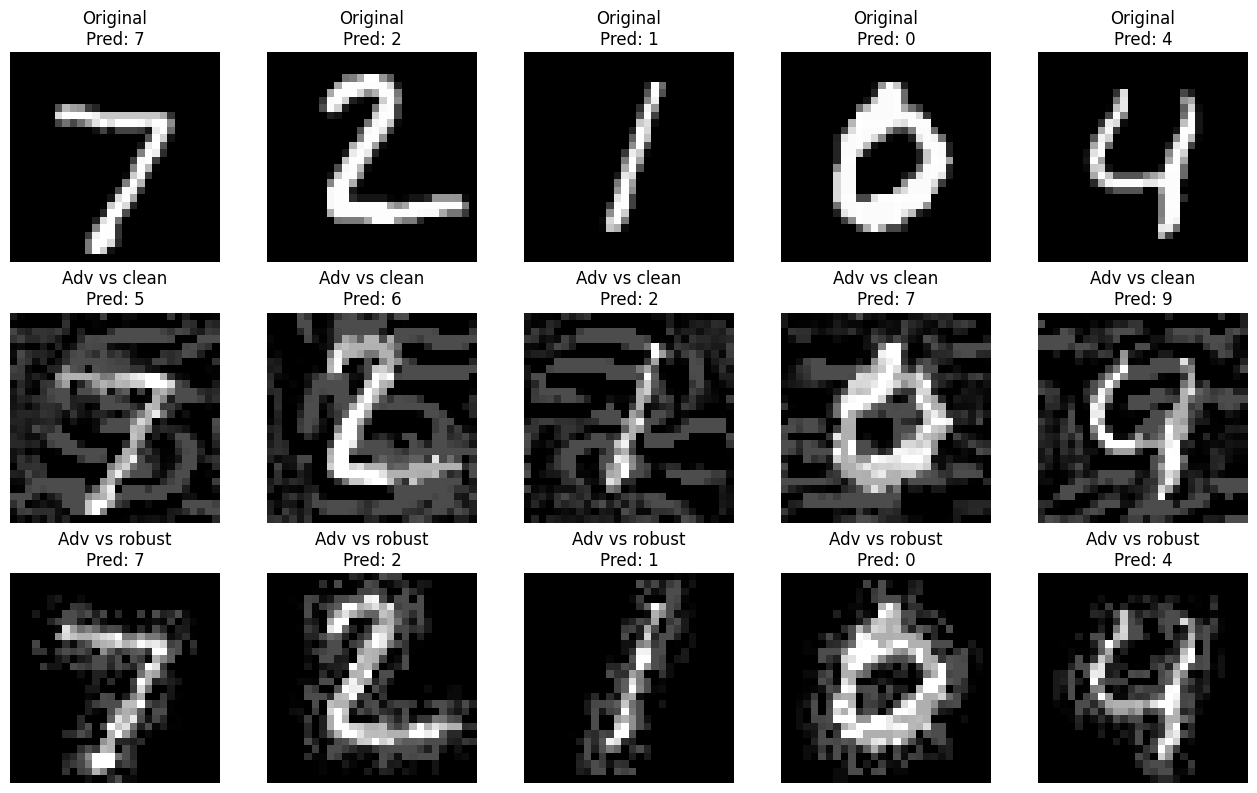

In [14]:
def show_adv_examples(model_clean, model_robust, attack_fn, eps=0.3, n=5):
    model_clean.eval()
    model_robust.eval()

    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)

    images = images[:n]
    labels = labels[:n]

    # Generate adversarial examples for clean model
    adv_clean = attack_fn(model_clean, images, labels)

    # Generate adversarial examples for robust model
    adv_robust = attack_fn(model_robust, images, labels)

    plt.figure(figsize=(13, 8))
    for i in range(n):

        # Original image
        plt.subplot(3, n, i+1)
        plt.imshow(images[i].squeeze().detach().cpu().numpy(), cmap="gray")
        pred_clean = model_clean(images[i].unsqueeze(0)).argmax(1).item()
        plt.title(f"Original\nPred: {pred_clean}")
        plt.axis("off")

        # Adversarial for CLEAN model
        plt.subplot(3, n, n + i + 1)
        plt.imshow(adv_clean[i].squeeze().detach().cpu().numpy(), cmap="gray")
        pred_adv_clean = model_clean(adv_clean[i].unsqueeze(0)).argmax(1).item()
        plt.title(f"Adv vs clean\nPred: {pred_adv_clean}")
        plt.axis("off")

        # Adversarial for ROBUST model
        plt.subplot(3, n, 2*n + i + 1)
        plt.imshow(adv_robust[i].squeeze().detach().cpu().numpy(), cmap="gray")
        pred_adv_robust = model_robust(adv_robust[i].unsqueeze(0)).argmax(1).item()
        plt.title(f"Adv vs robust\nPred: {pred_adv_robust}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_adv_examples(
    model_clean=model_clean,
    model_robust=model_robust,
    attack_fn=lambda m,x,y: pgd_attack(m, x, y, eps=0.3, alpha=0.01, iters=40),
    eps=0.3,
    n=5
)


## Accuracy comparison


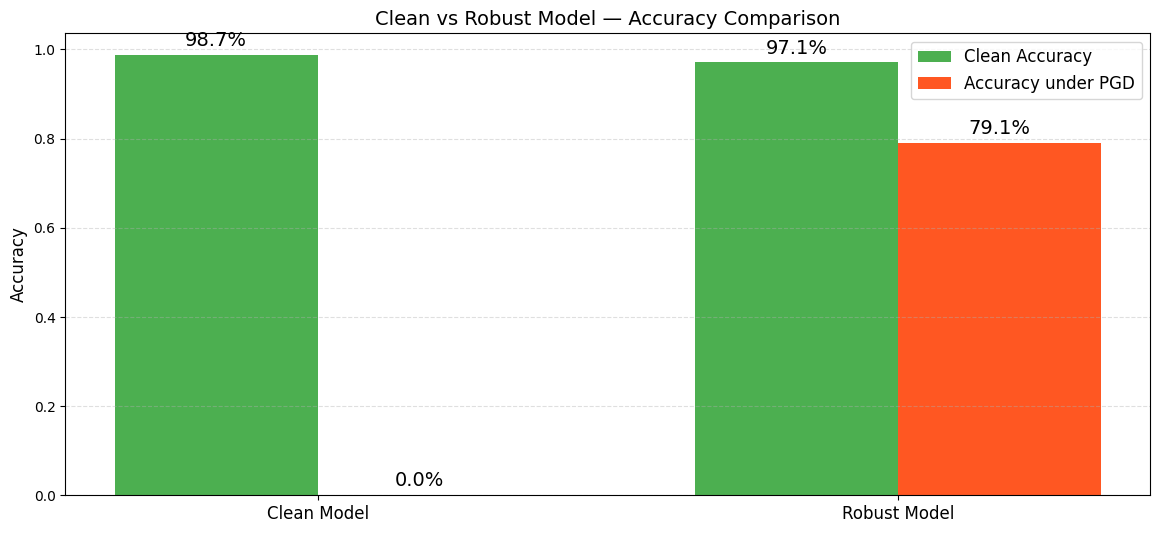

In [ ]:

clean_normal = acc_clean_clean
clean_robust = acc_robust_clean
pgd_normal   = acc_clean_pgd
pgd_robust   = acc_robust_pgd

labels = ["Clean Model", "Robust Model"]
clean_accs = [clean_normal, clean_robust]
pgd_accs   = [pgd_normal,   pgd_robust]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(14,6))
plt.bar(x - width/2, clean_accs, width, label='Clean Accuracy', color="#4CAF50")
plt.bar(x + width/2, pgd_accs, width, label='Accuracy under PGD', color="#FF5722")

plt.xticks(x, labels, fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Clean vs Robust Model — Accuracy Comparison", fontsize=14)

plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

for i, v in enumerate(clean_accs):
    plt.text(i - width/2, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=14)

for i, v in enumerate(pgd_accs):
    plt.text(i + width/2, v + 0.02, f"{v*100:.1f}%", ha='center', fontsize=14)

plt.show()


# General Conclusion

Through this project, we explored several adversarial attacks (FGSM, PGD, DeepFool) and evaluated their impacts on MNIST and CIFAR-10.  
These attacks revealed the severe vulnerability of standard neural networks: even imperceptible perturbations can cause nearly 100% misclassification under PGD.

To address this, we implemented **PGD adversarial training**, a defense mechanism that integrates adversarial examples directly into the training process.  
Our results demonstrate that adversarial training substantially improves robustness:

- The standard model collapses under PGD attacks (0% accuracy),  
- while the PGD-trained model preserves **~79% accuracy**, despite a slight reduction in clean accuracy.

This trade-off highlights an essential principle in robust machine learning:  
**models can become significantly more resilient, but robustness requires additional computation and may reduce performance on clean data.**

Overall, this part of the project validates the effectiveness of adversarial training and provides a strong foundation for exploring more advanced robustness techniques, transferability analysis, or robust architectures in future work.
